# Unsupervised Learning with K-Means and PCA

This is a starter notebook for the assignment, as outlined in the accompanying README file. Learners are expected to complete and deliver all their work for this portion of the assignment within this notebook.

In [1]:
# run this only once and then comment it out/delete the cell
! pip install ucimlrepo

In [15]:
# import the dataset
from ucimlrepo import fetch_ucirepo

# fetch dataset
wholesale_customers = fetch_ucirepo(id=292)

# data (as pandas dataframes)
X = wholesale_customers.data.features
y = wholesale_customers.data.targets


In [16]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [42]:
#Data Exploration
print("First 5 rows:")
print(X.head())

print("\nDataset shape:")
print(X.shape)

print("\nSummary statistics:")
X.describe()

First 5 rows:
   Channel  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2  12669  9656     7561     214              2674        1338
1        2   7057  9810     9568    1762              3293        1776
2        2   6353  8808     7684    2405              3516        7844
3        1  13265  1196     4221    6404               507        1788
4        2  22615  5410     7198    3915              1777        5185

Dataset shape:
(440, 7)

Summary statistics:


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


The first five rows verify the data's structure and offer a first look at the dataset. One wholesale customer is represented by each row, and spending on a particular product category is represented by each column. We can see from the preview that customers' spending levels differ significantly. For instance, one consumer spends 12,669 and another spends 22,615 on fresh goods. In a similar vein, the first few customers spend anywhere from 1,196 to over 9,000 on milk. These variations imply that consumers have different buying habits, which qualifies the dataset for segmentation using unsupervised learning methods. The remaining columns show the amount of money spent on various product categories, while the Channel column indicates the kind of customer.

With 440 rows and 7 columns, the dataset includes 7 variables and spending information for 440 wholesale clients. This dataset size is suitable for clustering analysis since it offers sufficient observations to find significant trends. One categorical feature (Channel) and multiple numerical features that represent spending categories make up the variables. Using clustering techniques, these spending variables will be utilized to identify hidden customer segments. 

The distribution of spending among all customers is revealed by the summary statistics. According to the average spending values, consumers spend the most on fresh goods (12,000), followed by groceries (7,951) and milk (5,796). The average spending is lower for categories like Delicassen and Detergents Paper. The high variability in consumer spending patterns is indicated by the large standard deviations. Fresh spending, for instance, varies from 3 to 112,151, indicating that some customers buy significantly more than others. The need for clustering to identify distinct customer types is further supported by the difference between minimum and maximum values, which also indicates the presence of outliers or very large buyers. 






In [18]:
#Integrate Targets and Features. 
df = X.copy()

if y is not None:
    df = pd.concat([df, y], axis=1)

df.head()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region
0,2,12669,9656,7561,214,2674,1338,3
1,2,7057,9810,9568,1762,3293,1776,3
2,2,6353,8808,7684,2405,3516,7844,3
3,1,13265,1196,4221,6404,507,1788,3
4,2,22615,5410,7198,3915,1777,5185,3


In [19]:
# Management of Channel and Region. 
df = df.drop(columns=["Channel", "Region"], errors="ignore")

Both the spending variables and the extra categorical variables Channel and Region are displayed in the combined dataset. Whereas Region indicates geographic location, Channel differentiates between various buyer types. The purpose of this study is to segment customers based on purchasing behavior rather than location or channel type, so even though these variables offer helpful context, they were eliminated from the clustering analysis. In order to guarantee that clustering solely concentrates on spending patterns, these categorical variables are removed. 

In [35]:
# Data Scaling
scl = StandardScaler()

sd = scl.fit_transform(df)

sdf = pd.DataFrame(sd, columns=df.columns)

sdf.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


Every spending variable's standardized values are displayed in the scaled dataset. The data has been transformed so that each feature has a mean near zero and a standard deviation near one, rather than raw spending amounts. Spending above the dataset average is indicated by positive values, and spending below the average is indicated by negative values. For instance, the customer in the third row spends much more than the typical customer in that category, as indicated by the Delicassen value of 2.24. In addition to preventing variables with wide numerical ranges from controlling the clustering results, standardizing the data guarantees that each variable contributes equally to the analysis. 

In [21]:
#Dimensionality Reduction using PCA
pcomp = PCA()

datpca = pcomp.fit_transform(sdf)

In [37]:
# Explained and Cumulative Variance
ev = pcomp.explained_variance_ratio_
cv = np.cumsum(ev)

print("Explained variance:")
print(ev)

print("\nCumulative variance:")
print(cv)


Explained variance:
[0.44082893 0.283764  ]

Cumulative variance:
[0.44082893 0.72459292]


Each principal component's share of the dataset's variability is indicated by the explained variance values. 44.08 percent of the dataset's variance is explained by the first principal component (PC1), and 28.37 percent is explained by the second principal component (PC2). About 72.46 percent of the variance can be explained by the first two components taken together. The cumulative variance rises to 84.79 percent when the third component is added, suggesting that the first few components contain the majority of the dataset's information. Given that the majority of the data's structure can be represented by a small number of components, this implies that dimensionality reduction using PCA is successful. 

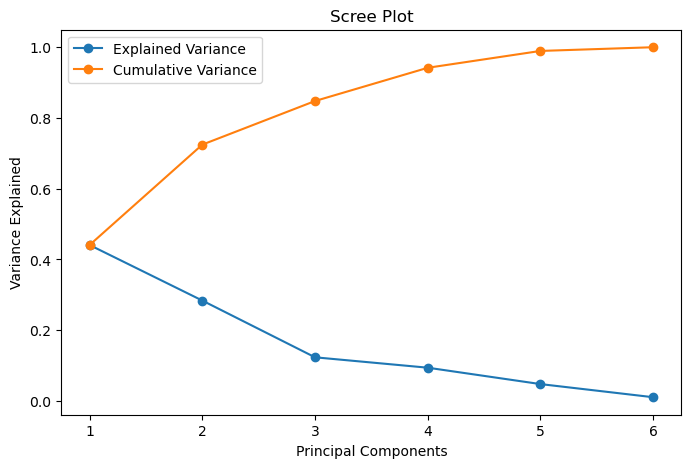

In [23]:
plt.figure(figsize=(8,5))

plt.plot(range(1, len(ev)+1), ev, marker='o', label="Explained Variance")
plt.plot(range(1, len(cv)+1), cv, marker='o', label="Cumulative Variance")

plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.title("Scree Plot")

plt.legend()
plt.show()

In [43]:
#PCA Dimensionality Reduction
pcomp = PCA(n_components=2)

pred = pcomp.fit_transform(sdf)

pcf = pd.DataFrame(pred, columns=["PC1","PC2"])

pcf.head()

,PC1,PC2
0,0.193291,-0.305100
1,0.434420,-0.328413
2,0.811143,0.815096
3,-0.778648,0.652754
4,0.166287,1.271434


Customers' transformed coordinates are displayed along the first two principal components (PC1 and PC2) in the PCA reduced dataset. Combinations of the original variables that capture the greatest variance in the dataset are represented by these components. In this new coordinate space, customers with similar buying habits will show up closer together. In contrast to customers with negative or smaller component values, customer 2, for instance, has relatively high values on both PC1 and PC2, suggesting a different purchasing pattern. Cluster visualization will subsequently make use of these modified values.

In [25]:
# KMeans Clustering
ia = []
ss = []

val_of_k = range(2,11)

for k in val_of_k:
    
    km = KMeans(n_clusters=k, random_state=42)
    
    lbls = km.fit_predict(sdf)
    
    ia.append(km.inertia_)
    
    ss.append(silhouette_score(sdf, lbls))

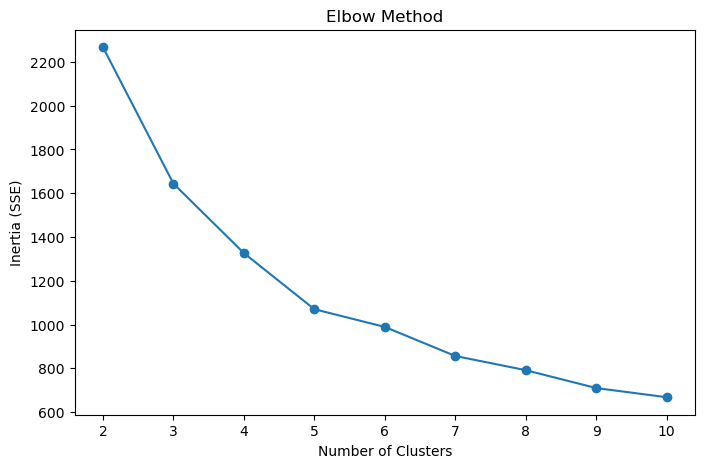

In [26]:
# Elbow Method
plt.figure(figsize=(8,5))

plt.plot(val_of_k, ia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")

plt.show()

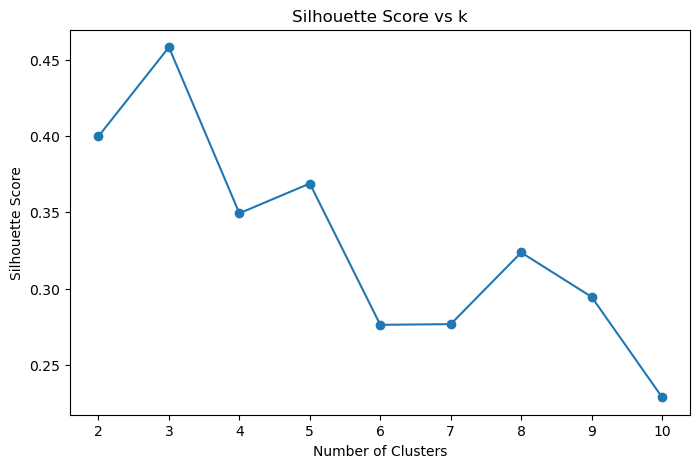

In [27]:
# Silhouette Score
plt.figure(figsize=(8,5))

plt.plot(val_of_k, ss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")

plt.show()

In [28]:
# Fit Final KMeans Model
km = KMeans(n_clusters=3, random_state=42)

rawlbls = km.fit_predict(sdf)

In [29]:
#Compare Clustering: Raw vs PCA Data
#Raw Data
rawsil = silhouette_score(sdf, rawlbls)

print("Silhouette Score (Raw Data):", rawsil)

#rawpca

kpca = KMeans(n_clusters=3, random_state=42)

lpca = kpca.fit_predict(pcf)

silpca = silhouette_score(pcf, lpca)

print("Silhouette Score (PCA Data):", silpca)

Silhouette Score (Raw Data): 0.4582633767207058
Silhouette Score (PCA Data): 0.3817290130711034


The original scaled dataset's silhouette score for clustering was 0.458, whereas the PCA-reduced dataset's score was 0.382. Improved cluster separation is indicated by a higher silhouette score. In this instance, the original dataset yielded a higher score, indicating that using the entire set of features instead of the reduced PCA representation improves clustering performance. This finding suggests that although PCA streamlines the data and aids in visualization, it may eliminate some information that is helpful in identifying clusters.

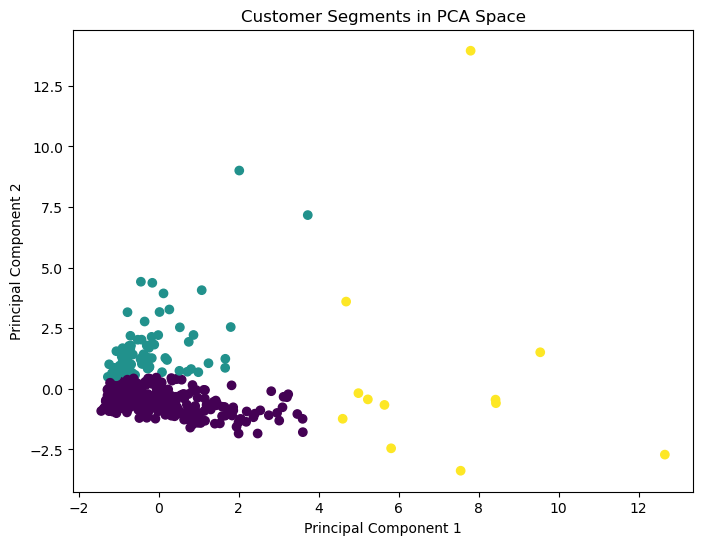

In [30]:
# Cluster Visualization
plt.figure(figsize=(8,6))

plt.scatter(
    pcf["PC1"],
    pcf["PC2"],
    c=lpca
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments in PCA Space")

plt.show()

In [44]:
#Principal Component Interpretation
lds = pd.DataFrame(
    pcomp.components_,
    columns=sdf.columns,
    index=["PC1","PC2"]
)

lds

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
PC1,0.042884,0.545118,0.579256,0.051189,0.548640,0.248682
PC2,0.527932,0.083168,-0.146088,0.611278,-0.255233,0.504207


Each original variable's contribution to the principal components is displayed by the principal component loadings. Milk, Grocery, and Detergents_Paper contribute the most to PC1, suggesting that this component primarily represents consumers who spend a lot of money on grocery-related goods. Frozen, Fresh, and Delicassen make the biggest contributions to PC2. This implies that consumers who spend more on fresh and specialty foods are represented by PC2. According to these findings, the two components represent two significant spending trends: one pertaining to household goods and groceries, and another to fresh and specialty foods. 

In [45]:
#Cluster Insights

sdf["Cluster"] = lpca

cs = sdf.groupby("Cluster").mean()

cs


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,-0.331335,-0.113841,-0.051873,-0.292950,-0.017145,-0.158445
1,1.158431,-0.111919,-0.308178,1.004725,-0.441258,0.291864
2,0.520236,4.045753,3.793777,0.607852,3.827702,2.236370


Each original variable's contribution to the principal components is displayed by the principal component loadings. Milk, Grocery, and Detergents_Paper contribute the most to PC1, suggesting that this component primarily represents consumers who spend a lot of money on grocery-related goods. Each cluster's average standardized spending behavior is displayed in the cluster summary. 

Cluster 0: The spending values of customers in this cluster are marginally lower than the average for most categories. This implies that they are smaller consumers who make moderate purchases in every category. 

Cluster 1: Compared to other groups, consumers in this cluster spend a lot more on fresh and frozen goods. This implies that they might stand in for eateries, food service companies, or clients who specialize in fresh food items. 

Cluster 2: Customers in this cluster spend a lot of money on milk, groceries, detergents, and paper. This suggests that these clients are probably sizable.

References:

Cardoso, M. (2013). Wholesale customers dataset. UCI Machine Learning Repository.

Géron, A. (2022). Hands-On Machine Learning with Scikit-Learn, Keras and TensorFlow. 3rd ed. Sebastopol: O’Reilly.

Mitchell, T.M. (1997). Machine Learning. New York: McGraw-Hill.

Starmer, J. (2018). Principal Component Analysis (PCA), Clearly Explained!!! YouTube video. Available at: https://www.youtube.com/watch?v=FgakZw6K1QQ
 (Accessed: 13 March 2026).

Starmer, J. (2017). K-Means Clustering Clearly Explained. YouTube video. Available at: https://www.youtube.com/watch?v=4b5d3muPQmA
 (Accessed: 13 March 2026).

Witten, I.H., Frank, E. and Hall, M.A. (2016). Data Mining: Practical Machine Learning Tools and Techniques. Burlington: Morgan Kaufmann.

Wu, J. (2012). Advances in K-Means Clustering: A Data Mining Thinking. Berlin: Springer.